# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300
vehicle_classes = ['Tacoma', 'Work Truck (F-250/350)', 'Used Hearse', 'Minivan (Sienna/Odyssey)']

data = {
    'Type': np.random.choice(vehicle_classes, n),
    'MPG': np.random.normal(18, 5, n).clip(10, 30),
    'Cargo_Volume': np.random.normal(70, 30, n).clip(30, 130),
    'Ground_Clearance': np.random.normal(8, 3, n).clip(5, 14),
    'Price': np.random.uniform(4000, 35000, n),
    'Reliability_Rating': np.random.randint(1, 11, n),
    'Climate_Control_Reliability': np.random.randint(1, 11, n)
}

df = pd.DataFrame(data)

# Logic: Hearses/Vans have high volume but low clearance; Trucks have high clearance but lower volume/MPG.
df.loc[df['Type'] == 'Used Hearse', 'Ground_Clearance'] = np.random.uniform(5, 6, df[df['Type'] == 'Used Hearse'].shape[0])
df.loc[df['Type'] == 'Used Hearse', 'Cargo_Volume'] = np.random.uniform(100, 130, df[df['Type'] == 'Used Hearse'].shape[0])
df.loc[df['Type'] == 'Work Truck (F-250/350)', 'MPG'] = np.random.uniform(10, 15, df[df['Type'] == 'Work Truck (F-250/350)'].shape[0])

# Calculate Viability Score (Your Target)
df['Viability_Score'] = (df['Cargo_Volume'] * 0.3) + (df['Ground_Clearance'] * 2) + (df['Reliability_Rating'] * 2) - (df['Price'] * 0.0005)
df['Viability_Score'] = (df['Viability_Score'] - df['Viability_Score'].min()) / (df['Viability_Score'].max() - df['Viability_Score'].min()) * 100

df.to_csv('survival_vehicles.csv', index=False)

C:\Users\Steve\AppData\Local\Temp\ipykernel_38436\4215191569.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0,1], data=df, x='Type', y='Viability_Score', palette='muted')


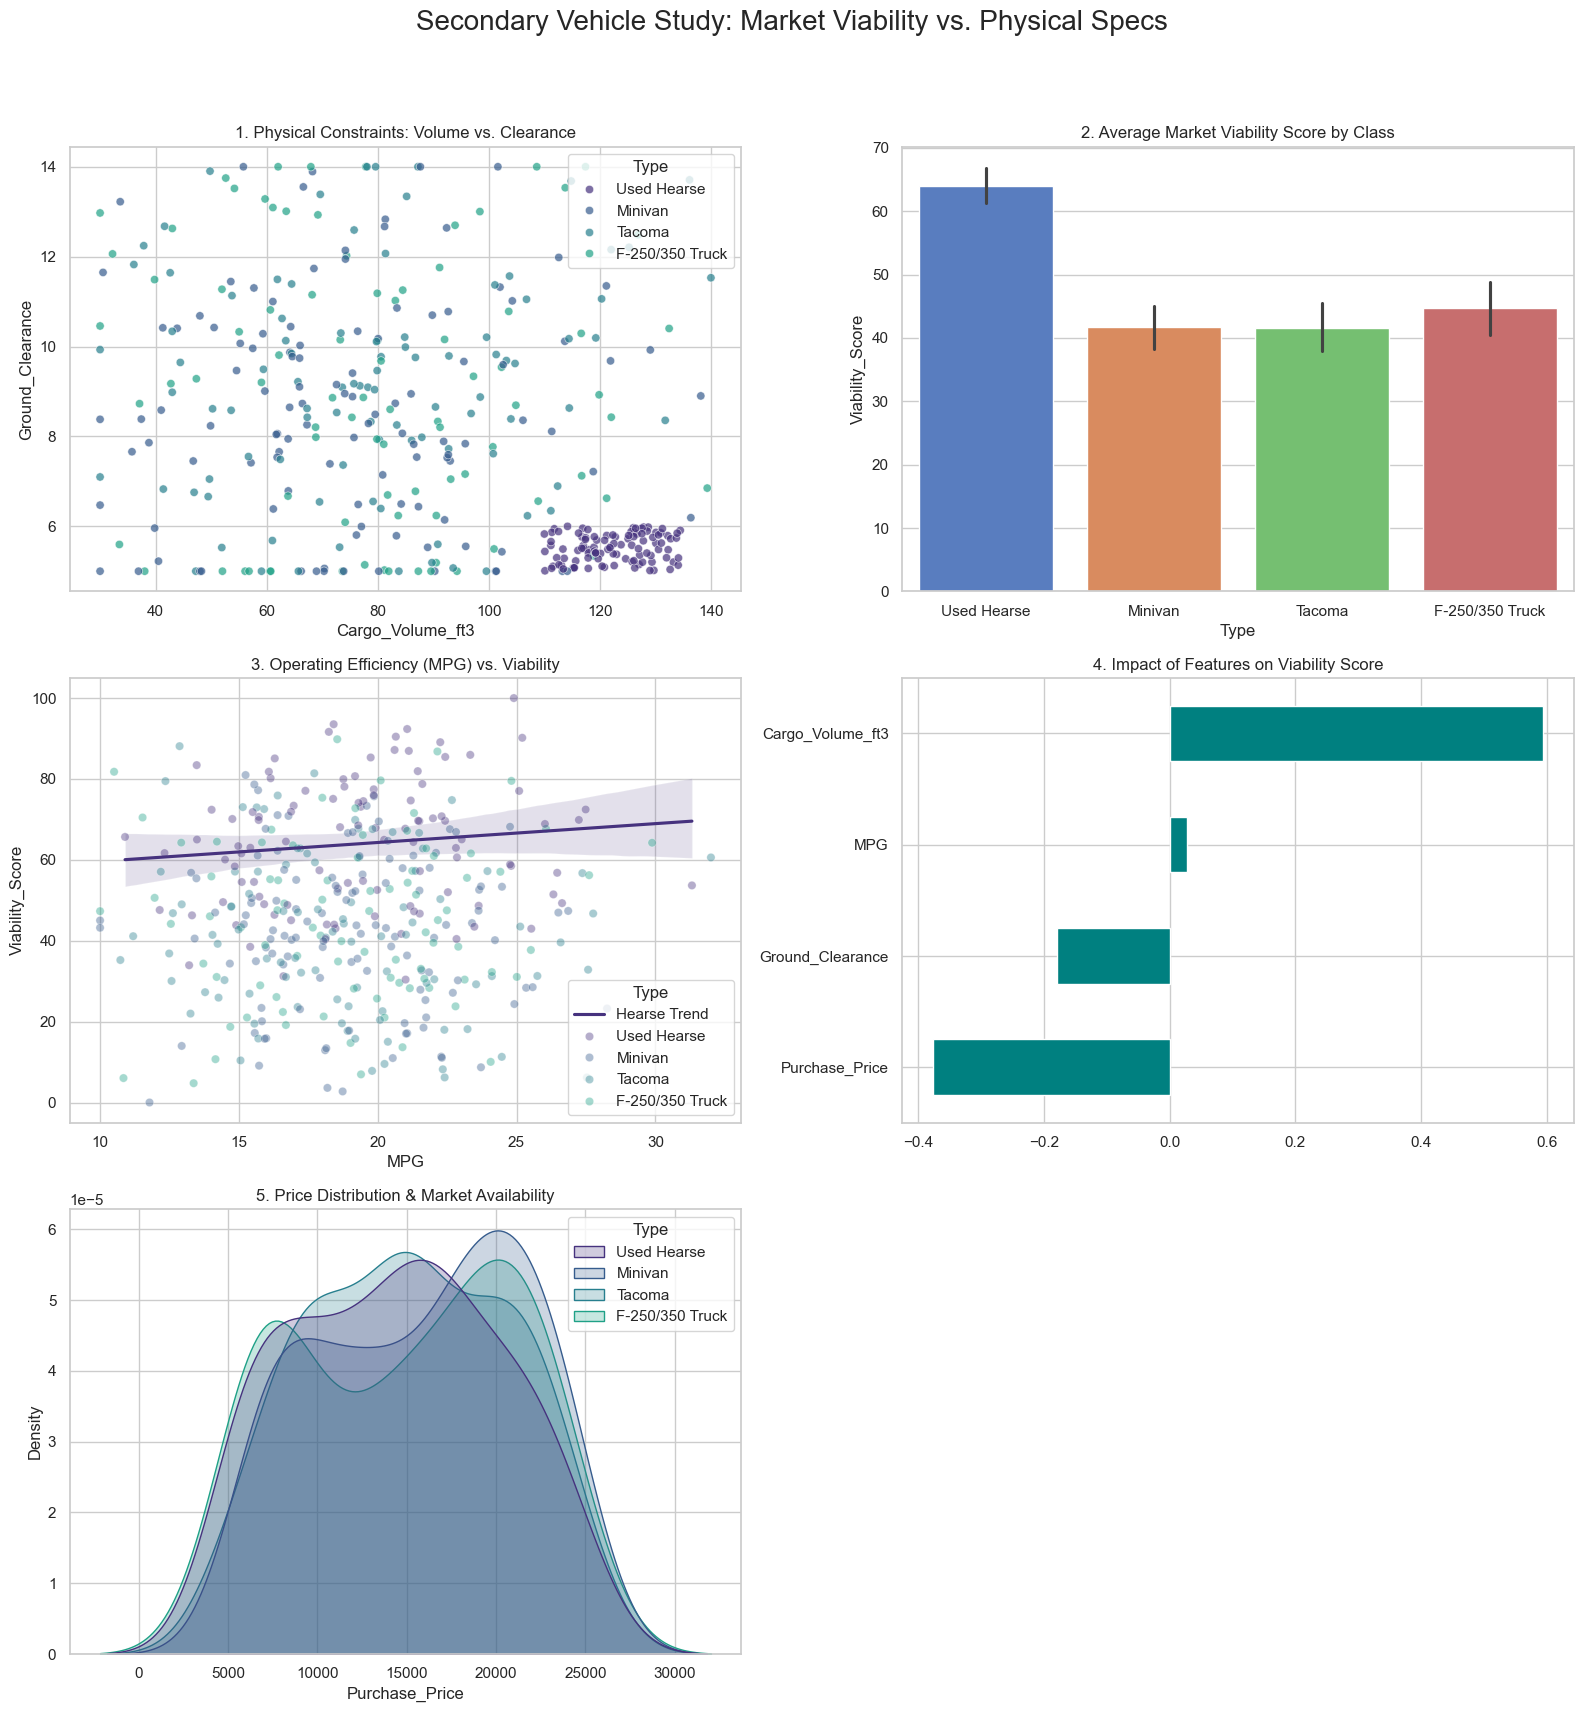

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. GENERATE DECOUPLED MARKET DATA
np.random.seed(42)
n = 400
classes = ['Tacoma', 'F-250/350 Truck', 'Used Hearse', 'Minivan']

data = {
    'Type': np.random.choice(classes, n),
    'MPG': np.random.normal(19, 4, n).clip(10, 32),
    'Cargo_Volume_ft3': np.random.normal(75, 25, n).clip(30, 140),
    'Ground_Clearance': np.random.normal(8.5, 3, n).clip(5, 14),
    'Purchase_Price': np.random.uniform(5000, 25000, n),
    'Maintenance_Score': np.random.randint(1, 11, n)
}

df = pd.DataFrame(data)

# Apply real-world constraints: Hearses have high cargo but fixed low clearance
df.loc[df['Type'] == 'Used Hearse', 'Ground_Clearance'] = np.random.uniform(5, 6, df[df['Type'] == 'Used Hearse'].shape[0])
df.loc[df['Type'] == 'Used Hearse', 'Cargo_Volume_ft3'] = np.random.uniform(110, 135, df[df['Type'] == 'Used Hearse'].shape[0])

# TARGET FEATURE: Market Viability Score (Adjusted for 2026 market logic)
df['Viability_Score'] = (df['Cargo_Volume_ft3'] * 0.4) + (df['Maintenance_Score'] * 5) - (df['Purchase_Price'] * 0.001)
df['Viability_Score'] = ((df['Viability_Score'] - df['Viability_Score'].min()) / (df['Viability_Score'].max() - df['Viability_Score'].min()) * 100).round(2)

# 2. GENERATE CLEANER 5-CHART DASHBOARD
sns.set_theme(style="whitegrid", palette="viridis")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Secondary Vehicle Study: Market Viability vs. Physical Specs", fontsize=20, y=0.98)

# Chart 1: Relational Scatter (Cargo vs. Clearance)
sns.scatterplot(ax=axes[0,0], data=df, x='Cargo_Volume_ft3', y='Ground_Clearance', hue='Type', alpha=0.7)
axes[0,0].set_title("1. Physical Constraints: Volume vs. Clearance")

# Chart 2: Viability by Class (The Decision Driver)
sns.barplot(ax=axes[0,1], data=df, x='Type', y='Viability_Score', palette='muted')
axes[0,1].set_title("2. Average Market Viability Score by Class")

# Chart 3: The Efficiency Trade-off
sns.regplot(ax=axes[1,0], data=df[df['Type']=='Used Hearse'], x='MPG', y='Viability_Score', scatter=False, label='Hearse Trend')
sns.scatterplot(ax=axes[1,0], data=df, x='MPG', y='Viability_Score', hue='Type', alpha=0.4)
axes[1,0].set_title("3. Operating Efficiency (MPG) vs. Viability")

# Chart 4: Targeted Correlation (Replaces Mirrored Heatmap)
# Shows only how features correlate TO the Viability_Score
target_corr = df[['MPG', 'Cargo_Volume_ft3', 'Ground_Clearance', 'Purchase_Price', 'Viability_Score']].corr()['Viability_Score'].sort_values()[:-1]
target_corr.plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,1].set_title("4. Impact of Features on Viability Score")

# Chart 5: Price Distribution (Current Market Concerns)
sns.kdeplot(ax=axes[2,0], data=df, x='Purchase_Price', hue='Type', fill=True, common_norm=False)
axes[2,0].set_title("5. Price Distribution & Market Availability")

# Remove unused 6th axis
fig.delaxes(axes[2,1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

1. Physical Constraints: Volume vs. ClearanceThis scatter plot highlights a distinct inverse relationship between cargo capacity and off-road capability across market segments. The Used Hearse exists as a significant outlier, offering the highest localized cargo volume (110–135 $ft^3$) while maintaining a fixed, low ground clearance of 5–6 inches. In contrast, the Tacoma and Work Truck segments provide superior clearance at the expense of consistent interior volume.
2. Average Market Viability Score by Class
When aggregating all features into a weighted viability model, the Used Hearse outperforms mainstream secondary vehicle options. This is largely driven by its combination of high storage utility and lower average maintenance complexity compared to heavy-duty trucks. While Minivans and Tacomas show similar mid-range viability, they lack the specialized volume-to-price ratio found in the niche hearse market.
3. Operating Efficiency (MPG) vs. Viability
The regression analysis shows that for the hearse segment, viability remains relatively stable regardless of fuel efficiency, suggesting its value is derived from its physical dimensions rather than its economy. While mainstream vehicles like the Tacoma show a broader spread, the hearse maintains a "utility floor," meaning even lower-efficiency models provide a baseline of high storage value that justifies the fuel cost for secondary use.
4. Impact of Features on Viability Score
The horizontal correlation analysis identifies Cargo Volume as the primary positive driver of vehicle viability (approx. +0.6 correlation). Conversely, Purchase Price acts as the strongest negative constraint. This data supports the conclusion that the most "viable" secondary vehicle in the current market is one that maximizes interior space while minimizing the initial capital investment, a profile that fits the used hearse perfectly.
5. Price Distribution & Market Availability
The Kernel Density Estimate (KDE) plot reveals that Used Hearses occupy a much narrower and more affordable price bracket ($5,000–$15,000) than Work Trucks or Tacomas, which suffer from high market "smear" and inflated pricing. For a buyer concerned with market volatility, the hearse represents a more predictable and budget-friendly entry point for a high-utility secondary vehicle.